# To investigate why the graphs look the way they do when the bound on the precomputation cost is higher

## Imports

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, e, log
from functions import *
from scipy.optimize import minimize, Bounds

## Constants

In [12]:
N = 2 ** 20
p = 1-e**-2 # our table coverage

## Check original graphs are produced with new functions

In [13]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha):   # add v_cost if want vanilla cost to be set beforehand
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    
    ## set the bound and target function
    # lower bounds and upper bounds for the input variables
    bound = Bounds([1 for i in range(t)], [float("inf") for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = vanilla_cost(N, m_0, t)
    v_cost = v_cost * 1.125
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    # P(vanilla) - P(cherry) > 0 the same precomputation cost
    # but want the vanilla cost to be set beforehand
    # ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    res = minimize(lambda Kj: m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps":0.5})
    
    ## res.x is the result of the optimization
    print(m_0)
    print(t)
    print(len(res.x))
    final_cost, m_values = cost(res.x, N, m_0) # calculate the final cost and m values
    print(f"Final cost: {final_cost}")
    print(f"Final m_t: {m_values[-1]}")
    return res.x, m_0, final_cost, m_values

## Run the function

In [14]:
def test_m0():
    # different maximality factors
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    results = []
    
    for alpha in alphas:
        K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha)
        results.append([K_js, m_0, final_cost, m_values])
        
        plot_kjs(K_js, m_0, alpha, "$2^{20}$")
        
    return results

Optimization terminated successfully    (Exit mode 0)
            Current function value: -8339.804541302941
            Iterations: 146
            Function evaluations: 29784
            Gradient evaluations: 146
20643
202
202
Final cost: 2588274.2733284174
Final m_t: 8339.804541302941
Optimization terminated successfully    (Exit mode 0)
            Current function value: -8914.040844513402
            Iterations: 133
            Function evaluations: 27143
            Gradient evaluations: 133
25803
202
202
Final cost: 2952765.7916423385
Final m_t: 8914.040844513402
Optimization terminated successfully    (Exit mode 0)
            Current function value: -9574.379046679082
            Iterations: 142
            Function evaluations: 28948
            Gradient evaluations: 142
34404
202
202
Final cost: 3458321.129244786
Final m_t: 9574.379046679082
Optimization terminated successfully    (Exit mode 0)
            Current function value: -9943.512057729198
            Iterations: 1

[[array([ 1.        ,  1.        ,  1.        ,  1.26832841,  1.24606879,
          1.81496412,  1.87643972,  2.14210979,  2.40612853,  2.39255954,
          2.98219873,  3.38871081,  3.03654787,  3.07188178,  3.35163744,
          3.75632192,  4.26918607,  4.69386952,  5.05765836,  5.38479417,
          5.63290655,  5.79202019,  5.95106283,  6.08706861,  6.2188057 ,
          6.33251825,  6.49635024,  6.79308942,  7.02431669,  7.24057316,
          7.63139839,  7.93788575,  8.27174816,  8.66511317,  9.03667878,
          9.36887336,  9.80005198, 10.19932532, 10.4892845 , 10.80042754,
         11.10555946, 11.47797088, 11.84721704, 12.06335912, 12.46676231,
         12.77495365, 13.00688296, 13.28964691, 13.50818979, 13.82679506,
         14.04760306, 14.38440804, 14.56531818, 14.84278431, 15.05838022,
         15.35081473, 15.62199726, 15.82449923, 16.08250798, 16.35528999,
         16.6431399 , 16.96156488, 17.19401418, 17.46485937, 17.73570148,
         18.07959351, 18.30502249, 18.

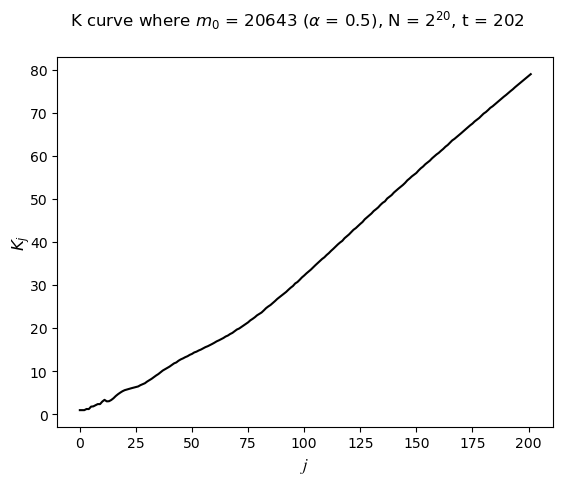

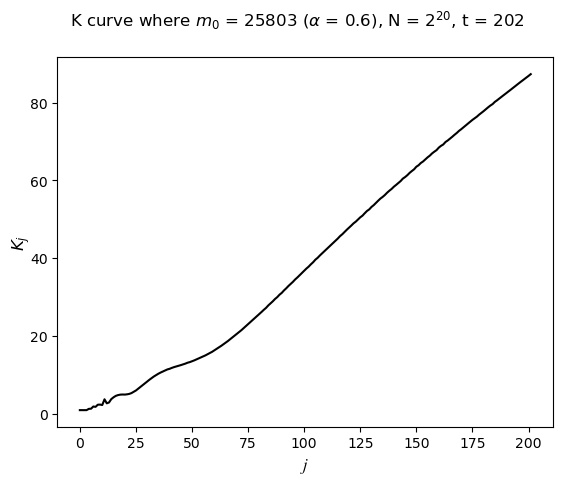

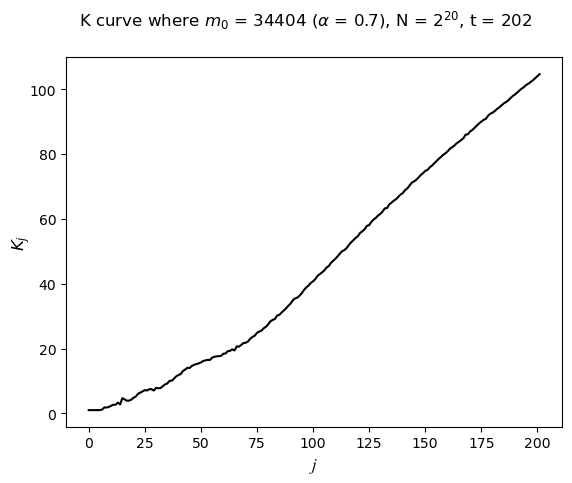

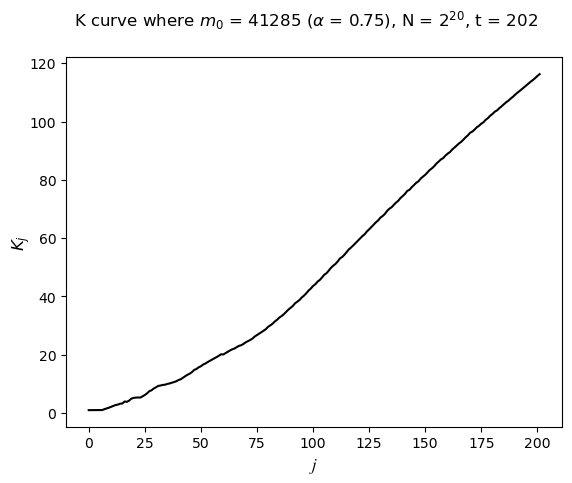

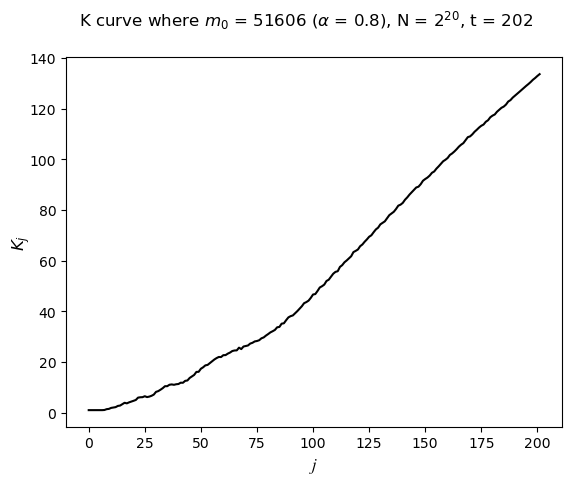

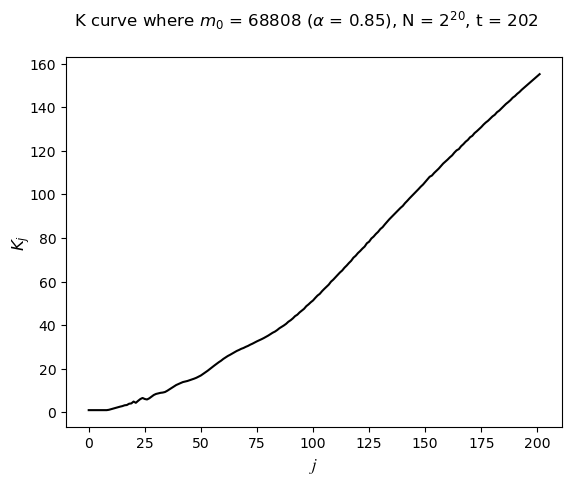

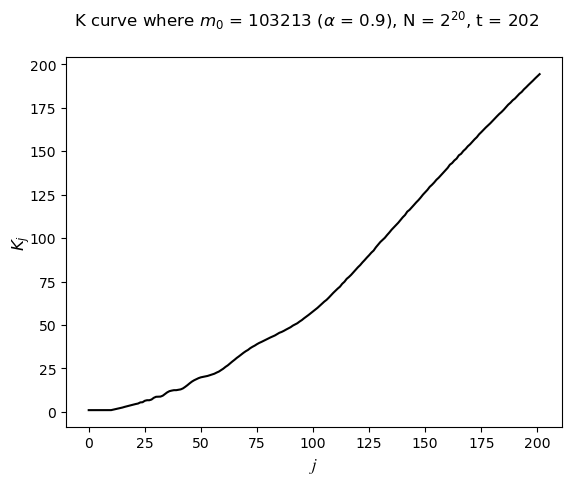

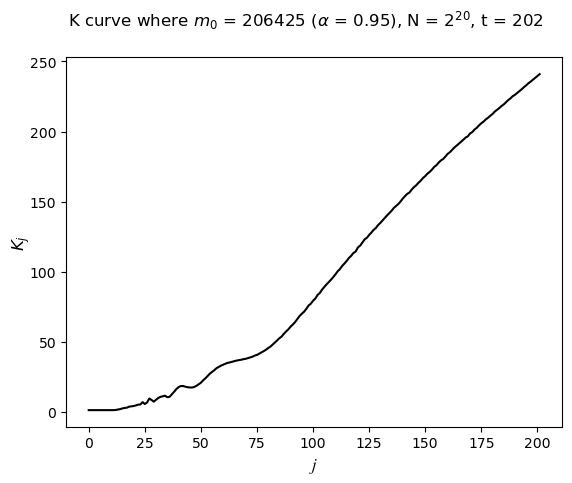

In [15]:
test_m0()